# Module 6 — Putting It Together: The Budget Decision
### Practical Statistics for Analysts @ Natural Intelligence

> **💬 Back to the Slack message:** *"Google converts better than Bing, mobile EPV is
> down, weekends are crashing — should we pull budget out of Bing and the weekend?"*

Now we answer it properly, end to end: pick the right metric, respect the
distribution, test the differences, quantify with intervals, and convert it all
into a **recommendation with a decision rule and a projected impact.**

The real objective isn't conversion rate *or* EPV — it's **profit per visit =
EPV − CPV**. That's what we optimize.

In [1]:
import sys
from pathlib import Path
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni
ni.set_style()

visits = ni.load_visits()
print(f"Loaded {len(visits):,} visits | {visits['date'].min().date()} -> {visits['date'].max().date()}")
visits.head()

Loaded 180,000 visits | 2026-03-01 -> 2026-05-30


,visit_id,date,day_of_week,is_weekend,engine,device,vertical,converted,revenue,cost,profit
0,1,2026-03-01,Sun,True,Bing,mobile,vpn,0,0.0000,0.8094,-0.8094
1,2,2026-03-01,Sun,True,Organic,tablet,vpn,0,0.0000,0.1886,-0.1886
2,3,2026-03-01,Sun,True,Google,tablet,web_builders,0,0.0000,3.6039,-3.6039
3,4,2026-03-01,Sun,True,Google,desktop,dating,1,10.0945,1.0836,9.0109
4,5,2026-03-01,Sun,True,Google,desktop,streaming,1,5.6453,0.8228,4.8225


## 1. The full funnel, by engine × device — with uncertainty

One table that an analyst can actually take to a meeting: volume, conversion (with
CI), EPV (with bootstrap CI), cost, **profit per visit (with CI)**, and ROAS.

In [2]:
def segment_stats(df):
    n = len(df); k = int(df.converted.sum())
    cr, cr_lo, cr_hi = ni.wilson_ci(k, n)
    epv, epv_lo, epv_hi = ni.bootstrap_mean_ci(df.revenue.values, n_boot=1500, seed=1)
    cpv = df.cost.mean()
    ppv, ppv_lo, ppv_hi = ni.bootstrap_mean_ci(df.profit.values, n_boot=1500, seed=2)
    return pd.Series({
        "visits": n, "conv_rate": cr, "conv_lo": cr_lo, "conv_hi": cr_hi,
        "EPV": epv, "CPV": cpv, "profit_visit": ppv, "ppv_lo": ppv_lo, "ppv_hi": ppv_hi,
        "ROAS": df.revenue.sum()/df.cost.sum()})

seg = (visits.groupby(["engine","device"], observed=True)
       .apply(segment_stats, include_groups=False).reset_index())
seg = seg[seg.visits > 1500].sort_values("profit_visit", ascending=False)

show = seg.assign(
    conversion=lambda d: d.apply(lambda r: f"{r.conv_rate:.0%} [{r.conv_lo:.0%},{r.conv_hi:.0%}]", axis=1),
    EPV_=lambda d: d.EPV.map("${:.2f}".format),
    CPV_=lambda d: d.CPV.map("${:.2f}".format),
    profit=lambda d: d.apply(lambda r: f"${r.profit_visit:.2f} [${r.ppv_lo:.2f},${r.ppv_hi:.2f}]", axis=1),
    ROAS_=lambda d: d.ROAS.map("{:.2f}x".format),
)[["engine","device","visits","conversion","EPV_","CPV_","profit","ROAS_"]]
show.columns = ["engine","device","visits","conversion (95% CI)","EPV","CPV","profit/visit (95% CI)","ROAS"]
show.style.hide(axis="index").set_caption("NI funnel by engine × device (last quarter)")

engine,device,visits,conversion (95% CI),EPV,CPV,profit/visit (95% CI),ROAS
Organic,desktop,13403.000000,"42% [41%,43%]",$8.41,$0.94,"$7.48 [$7.02,$7.95]",8.97x
Organic,tablet,3135.000000,"44% [42%,45%]",$7.72,$0.90,"$6.82 [$5.97,$7.73]",8.58x
Organic,mobile,23066.000000,"41% [40%,42%]",$7.61,$0.94,"$6.67 [$6.29,$7.08]",8.12x
Google,desktop,30595.000000,"45% [44%,45%]",$9.19,$5.57,"$3.62 [$3.25,$4.04]",1.65x
Bing,desktop,10845.000000,"36% [35%,37%]",$7.39,$4.20,"$3.19 [$2.61,$3.82]",1.76x
Social,desktop,6084.000000,"29% [28%,31%]",$6.20,$3.27,"$2.93 [$2.35,$3.54]",1.90x
Google,mobile,52389.000000,"44% [44%,44%]",$8.42,$5.64,"$2.78 [$2.50,$3.09]",1.49x
Bing,tablet,2499.000000,"35% [33%,37%]",$6.95,$4.29,"$2.66 [$1.85,$3.47]",1.62x
Google,tablet,7150.000000,"45% [43%,46%]",$8.05,$5.47,"$2.58 [$1.95,$3.22]",1.47x
Bing,mobile,18783.000000,"34% [33%,35%]",$6.33,$4.20,"$2.13 [$1.56,$2.95]",1.51x


## 2. Where is the profit? A forest plot of profit-per-visit

Green = profitable to scale, red = losing money per visit. The CIs tell us which
calls are safe (interval clear of \$0) vs which need more data.

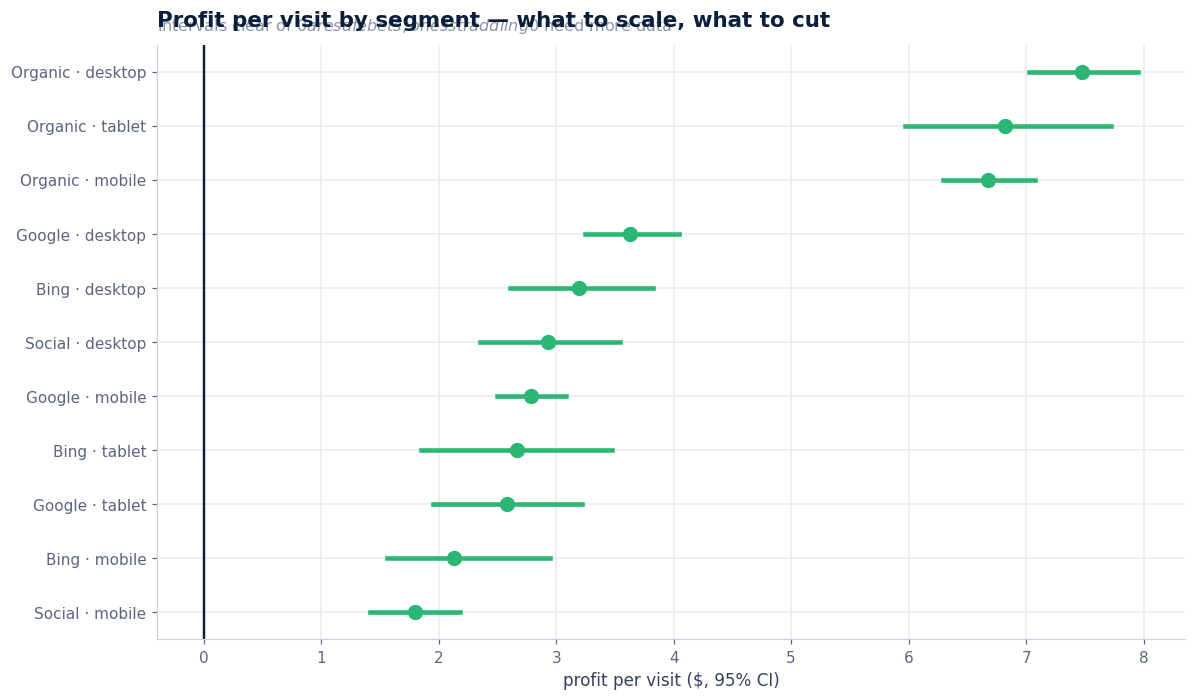

In [3]:
seg2 = seg.copy()
seg2["label"] = seg2.engine + " · " + seg2.device
seg2 = seg2.sort_values("profit_visit")
fig, ax = plt.subplots(figsize=(11, 6.5))
for i, (_, r) in enumerate(seg2.iterrows()):
    col = ni.GREEN if r.profit_visit > 0 else ni.RED
    ax.plot([r.ppv_lo, r.ppv_hi], [i, i], color=col, lw=3)
    ax.plot(r.profit_visit, i, "o", color=col, ms=9)
ax.axvline(0, color=ni.NAVY, lw=1.6)
ax.set_yticks(range(len(seg2))); ax.set_yticklabels(seg2.label)
ax.set_xlabel("profit per visit ($, 95% CI)")
ni.titlebox(ax, "Profit per visit by segment — what to scale, what to cut",
            "intervals clear of $0 are safe bets; ones straddling $0 need more data")
fig.tight_layout(); ni.savefig(fig, "m6_profit_forest"); plt.show()

## 3. A decision rule, and the projected impact

Every segment here is *profitable* — so the decision isn't "cut losers," it's
**"where should the next marginal dollar go?"** We bid only on **paid** engines
(Organic is free SEO — protect it, but it's not a budget lever), so we rank the
paid segments by **profit per visit** and reallocate.

**Rule:** *Scale up* the top third of paid segments; *trim bids* on the bottom third
(their profit/visit CI sits clearly below the leaders — Module 5). Then simulate
shifting 20% of the weakest segments' spend into the strongest.

Budget decision for PAID segments (we don't bid on Organic):

engine  device  visits  profit_visit  ppv_lo  ppv_hi         verdict
Google desktop 30595.0          3.62    3.25    4.04        SCALE UP
  Bing desktop 10845.0          3.19    2.61    3.82        SCALE UP
Social desktop  6084.0          2.93    2.35    3.54        SCALE UP
Google  mobile 52389.0          2.78    2.50    3.09 hold / optimize
  Bing  tablet  2499.0          2.66    1.85    3.47 hold / optimize
Google  tablet  7150.0          2.58    1.95    3.22            TRIM
  Bing  mobile 18783.0          2.13    1.56    2.95            TRIM
Social  mobile 10555.0          1.80    1.42    2.18            TRIM

Move ~7,297 visits/qtr from TRIM segments (avg $2.12/visit) to Google·desktop ($3.62/visit)


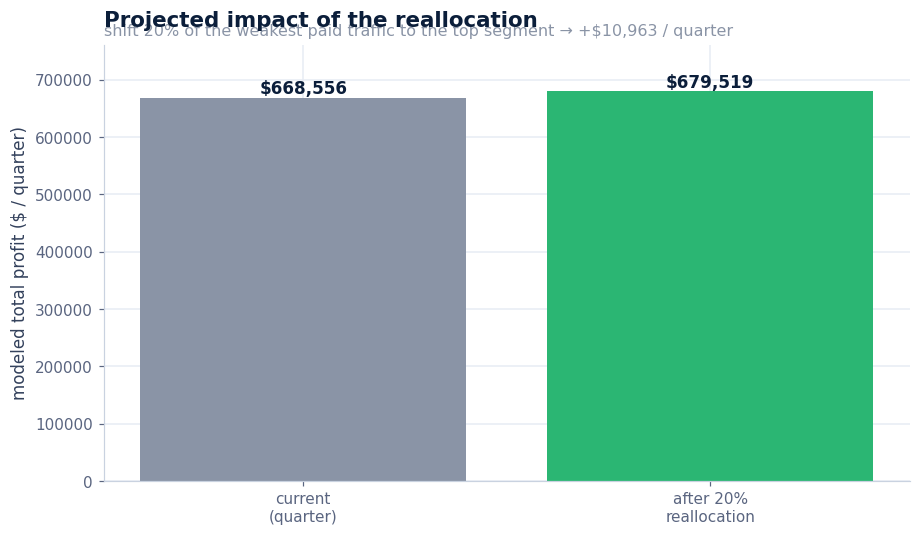

In [4]:
# We control bids on PAID engines only (Organic is free SEO, not a budget lever)
paid = seg[seg.engine != "Organic"].copy().sort_values("profit_visit")
lo_thr, hi_thr = paid.profit_visit.quantile([1/3, 2/3])
paid["verdict"] = np.where(paid.profit_visit >= hi_thr, "SCALE UP",
                   np.where(paid.profit_visit <= lo_thr, "TRIM", "hold / optimize"))
print("Budget decision for PAID segments (we don't bid on Organic):\n")
print(paid[["engine","device","visits","profit_visit","ppv_lo","ppv_hi","verdict"]]
      .round(2).sort_values("profit_visit", ascending=False).to_string(index=False))

# Reallocate 20% of the weakest ('TRIM') segments' traffic into the strongest segment
winners = paid[paid.verdict == "SCALE UP"]
losers  = paid[paid.verdict == "TRIM"]
top = winners.iloc[winners.profit_visit.values.argmax()]
moved_visits = int(0.20 * losers.visits.sum())
l_ppv = (losers.profit_visit * losers.visits).sum() / losers.visits.sum()
delta = moved_visits * (top.profit_visit - l_ppv)
print(f"\nMove ~{moved_visits:,} visits/qtr from TRIM segments (avg ${l_ppv:.2f}/visit) "
      f"to {top.engine}·{top.device} (${top.profit_visit:.2f}/visit)")

current = (seg.profit_visit * seg.visits).sum()
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(["current\n(quarter)","after 20%\nreallocation"], [current, current+delta],
       color=[ni.GREY, ni.GREEN])
for i, v in enumerate([current, current+delta]):
    ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontweight="bold", color=ni.NAVY)
ax.set_ylim(0, (current+delta)*1.12); ax.set_ylabel("modeled total profit ($ / quarter)")
ni.titlebox(ax, "Projected impact of the reallocation",
            f"shift 20% of the weakest paid traffic to the top segment → +${delta:,.0f} / quarter")
fig.tight_layout(); ni.savefig(fig, "m6_reallocation"); plt.show()

## 4. The answer to the Slack message

> **"Google converts better than Bing — should we pull budget out of Bing?"**
>
> ⚠️ **Don't kill Bing — conversion rate is the wrong yardstick.** Yes, Google's
> conversion edge is *real* (Module 4), **but budget follows profit per visit, not
> conversion rate.** Bing is still solidly profitable (positive profit/visit, CI
> clear of \$0 — Module 5), and its cheaper clicks partly offset the lower
> conversion. The right move is to **shift *marginal* budget toward the highest
> profit/visit segments (Google desktop leads), trim the weakest, and keep Bing for
> profitable volume** — not a blanket cut.
>
> ✅ **On mobile EPV:** that one *is* a real, quantified problem — mobile EPV is
> **5–20% below desktop** (Module 5). Trim mobile bids on the affected verticals
> and re-measure in two weeks.
>
> 🚫 **Ignore the "weekend EPV crash":** it's a **traffic-mix artifact** (Module 3) —
> weekends carry more low-payout entertainment traffic, not a real day effect.
> Don't touch weekend bidding because of it.
>
> 💡 **Bonus insight the data hands us:** *Organic* traffic earns ~8× ROAS (near-zero
> cost) — by far the most profitable. The biggest lever isn't engine reallocation at
> all; it's **protecting and growing SEO.**

## 🧾 The Statistical Decision Checklist (pin this at your desk)

| Step | Ask yourself |
|---|---|
| **1. Frame** | What's the unit, the outcome *type*, and what am I comparing? (Module 1) |
| **2. Look** | Did I plot the distribution? Is it skewed? Are there whales? (Module 2) |
| **3. Relate** | Is this correlation rank-based and confound-checked? (Module 3) |
| **4. Test** | Right test for the data shape? Enough power? How many tests did I run? (Module 4) |
| **5. Quantify** | What's the confidence interval — direction, magnitude, width? (Module 5) |
| **6. Decide** | Does it change **profit per visit**? What's the rule and the projected impact? (Module 6) |

> **The one-liner:** *Significance tells you something is there; the confidence
> interval tells you whether it's worth acting on; profit-per-visit tells you what to do.*

### 🎓 That's the workshop — from a Slack message to a defensible decision.

**→ The skill that automates this:** `/budget-decision`. Next: **Module 7 — compose the multi-agent flow** that runs all of this as one gated procedure.